# 🛒 E-Commerce Customer Churn & Sales Forecasting

### An End-to-End Data Science & Machine Learning Project

---

## 📌 Project Overview

This project analyzes e-commerce transaction data to understand customer purchasing behavior, predict future customer inactivity, and forecast sales.

The project combines data analytics, feature engineering, machine learning, and sales forecasting to generate actionable business insights.

### 🔍 Major Components

- 🧹 Data Cleaning & Preprocessing
- 📊 Exploratory Data Analysis
- 💰 Revenue Analysis
- 👥 Customer RFM Analysis
- 🤖 Customer Churn Prediction
- 🌲 Logistic Regression & Random Forest
- 📈 Sales Forecasting
- 💡 Business Insights

---

## 🎯 Objectives

1. Analyze historical e-commerce transaction data.
2. Clean and preprocess the dataset.
3. Calculate transaction-level revenue.
4. Identify monthly sales trends.
5. Analyze customer behavior using RFM features.
6. Predict future customer inactivity using machine learning.
7. Compare Logistic Regression and Random Forest.
8. Forecast future sales.
9. Present the findings through an interactive application.

---

## 🛠️ Technology Stack

| Technology | Purpose |
|---|---|
| Python | Programming |
| Pandas | Data manipulation |
| NumPy | Numerical operations |
| Matplotlib | Data visualization |
| Scikit-learn | Machine learning |
| Streamlit | Interactive application |
| Google Colab | Development |
| GitHub | Version control & project submission |

---

## 📂 Dataset

The project uses the **Online Retail II** transaction dataset.

The analysis currently focuses on the `Year 2010-2011` worksheet.

### Main Columns

- Invoice
- StockCode
- Description
- Quantity
- InvoiceDate
- Price
- Customer ID
- Country

## 📑 Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load Dataset](#2-load-dataset)
3. [Data Understanding](#3-data-understanding)
4. [Data Cleaning](#4-data-cleaning)
5. [Feature Engineering](#5-feature-engineering)
6. [Exploratory Data Analysis](#6-exploratory-data-analysis)
7. [Customer RFM Analysis](#7-customer-rfm-analysis)
8. [Time-Based Churn Modeling](#8-time-based-churn-modeling)
9. [Machine Learning](#9-machine-learning)
10. [Sales Forecasting](#10-sales-forecasting)
11. [Business Insights](#11-business-insights)
12. [Conclusion](#12-conclusion)

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


# 2. Load Dataset

In [83]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
file_path = '/content/drive/MyDrive/online_retail_II.xlsx'

df = pd.read_excel(
    file_path,
    sheet_name='Year 2010-2011'
)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (541910, 8)


In [6]:
# Display first 5 rows

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
# Check missing values

df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


# 3. Data Understanding

Before cleaning the dataset, we inspect its structure, data types, missing values, and duplicate records.

In [9]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (541910, 8)

Column Names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [10]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [11]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64


In [12]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 5268


# 4. Data Cleaning

The raw dataset is cleaned before performing analysis and machine learning.

The cleaning process includes:

1. Removing duplicate records
2. Identifying cancelled transactions
3. Removing negative quantities
4. Removing zero or negative prices
5. Handling missing customer IDs separately for churn analysis

In [13]:
# ============================================
# 4.1 REMOVE DUPLICATE RECORDS
# ============================================

print("Rows before removing duplicates:", len(df))

df = df.drop_duplicates().copy()

print("Rows after removing duplicates:", len(df))


Rows before removing duplicates: 541910
Rows after removing duplicates: 536642


## 4.2 Identify Cancelled Transactions

Cancelled invoices are identified using invoice numbers beginning with `C`.

These transactions represent cancellations and should not be included in normal sales calculations.

In [14]:
# Identify cancelled transactions

cancelled = df['Invoice'].astype(str).str.startswith('C')

print("Cancelled transactions:", cancelled.sum())

Cancelled transactions: 9251


In [15]:
# Remove cancelled transactions

df = df[~cancelled].copy()

print("Shape after removing cancelled transactions:", df.shape)

Shape after removing cancelled transactions: (527391, 8)


## 4.3 Remove Negative Quantities

Negative quantities generally represent returned or reversed items.

Since our primary sales analysis focuses on completed sales, these transactions are excluded.

In [16]:
print(
    "Negative quantity transactions:",
    (df['Quantity'] < 0).sum()
)

Negative quantity transactions: 1336


In [17]:
df = df[df['Quantity'] >= 0].copy()

print("Shape after removing negative quantities:", df.shape)

Shape after removing negative quantities: (526055, 8)


## 4.4 Remove Invalid Prices

Transactions with zero or negative prices cannot contribute meaningful positive sales revenue, so they are excluded from revenue analysis.

In [18]:
print(
    "Zero or negative prices:",
    (df['Price'] <= 0).sum()
)

Zero or negative prices: 1176


In [19]:
df = df[df['Price'] > 0].copy()

print("Shape after removing invalid prices:", df.shape)

Shape after removing invalid prices: (524879, 8)


In [20]:
print("Final cleaned dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Final cleaned dataset shape: (524879, 8)

Missing values:
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    132186
Country             0
dtype: int64

Duplicate rows:
0


# 5. Feature Engineering

Feature engineering transforms raw transaction data into meaningful variables that can be used for analysis and machine learning.

For this project, transaction-level revenue is calculated using:

**Revenue = Quantity × Price**

This feature will be used for sales analysis, customer analysis, and sales forecasting.

In [21]:
# ============================================
# 5.1 CALCULATE TRANSACTION REVENUE
# ============================================

df['Revenue'] = df['Quantity'] * df['Price']

# Round revenue to 2 decimal places
df['Revenue'] = df['Revenue'].round(2)

print("Revenue feature created successfully!")

Revenue feature created successfully!


In [22]:
df[['Quantity', 'Price', 'Revenue']].head()

,Quantity,Price,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [23]:
print("Total Revenue:", round(df['Revenue'].sum(), 2))
print("Average Transaction Revenue:", round(df['Revenue'].mean(), 2))
print("Maximum Transaction Revenue:", round(df['Revenue'].max(), 2))

Total Revenue: 10642128.8
Average Transaction Revenue: 20.28
Maximum Transaction Revenue: 168469.6


In [24]:
print("Negative revenue:", (df['Revenue'] < 0).sum())
print("Zero revenue:", (df['Revenue'] == 0).sum())

Negative revenue: 0
Zero revenue: 4


In [25]:
cleaned_file_path = '/content/drive/MyDrive/ecommerce_cleaned_2010_2011.csv'

df.to_csv(cleaned_file_path, index=False)

print("Cleaned dataset saved successfully!")
print(cleaned_file_path)

Cleaned dataset saved successfully!
/content/drive/MyDrive/ecommerce_cleaned_2010_2011.csv


In [26]:
print("Current Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Current Dataset Shape: (524879, 9)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue']


In [27]:
zero_revenue = df[df['Revenue'] == 0]

print("Zero-revenue rows:", len(zero_revenue))

zero_revenue[['Invoice', 'StockCode', 'Quantity', 'Price', 'Revenue']].head(10)

Zero-revenue rows: 4


,Invoice,StockCode,Quantity,Price,Revenue
157195,550193,PADS,1,0.001,0.0
279045,561226,PADS,1,0.001,0.0
359871,568200,PADS,1,0.001,0.0
361741,568375,BANK CHARGES,1,0.001,0.0


## 5.2 Remove Zero-Revenue Transactions

Four transactions generated zero revenue. Since the project focuses on sales revenue, these records are excluded from revenue-based analysis.

In [28]:
# Remove zero-revenue transactions

df = df[df['Revenue'] > 0].copy()

print("Zero-revenue transactions remaining:",
      (df['Revenue'] == 0).sum())

print("Dataset shape after revenue cleaning:", df.shape)

Zero-revenue transactions remaining: 0
Dataset shape after revenue cleaning: (524875, 9)


In [29]:
print("Final dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nRevenue statistics:")
print(df['Revenue'].describe())

Final dataset shape: (524875, 9)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue']

Revenue statistics:
count    524875.000000
mean         20.275549
std         271.694337
min           0.060000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64


# 6. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand overall sales performance, customer coverage, product diversity, geographic distribution, and sales trends.

The analysis uses the cleaned transaction dataset created in the previous section.

In [30]:
# ============================================
# 6.1 KEY BUSINESS METRICS
# ============================================

total_revenue = df['Revenue'].sum()

unique_orders = df['Invoice'].nunique()

unique_customers = df['Customer ID'].nunique()

unique_products = df['StockCode'].nunique()

unique_countries = df['Country'].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Unique Orders:", unique_orders)
print("Unique Customers:", unique_customers)
print("Unique Products:", unique_products)
print("Unique Countries:", unique_countries)

Total Revenue: 10642128.8
Unique Orders: 19960
Unique Customers: 4338
Unique Products: 3921
Unique Countries: 38


In [31]:
# Create a summary table

business_summary = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Unique Orders',
        'Unique Customers',
        'Unique Products',
        'Unique Countries'
    ],
    'Value': [
        round(total_revenue, 2),
        unique_orders,
        unique_customers,
        unique_products,
        unique_countries
    ]
})

business_summary

,Metric,Value
0,Total Revenue,10642128.8
1,Unique Orders,19960.0
2,Unique Customers,4338.0
3,Unique Products,3921.0
4,Unique Countries,38.0


## 6.2 Monthly Revenue Trend

Monthly revenue is calculated to identify sales patterns, seasonal variations, and high- and low-performing periods.

In [32]:
# Calculate monthly revenue

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

monthly_sales = (
    df.resample('ME', on='InvoiceDate')['Revenue']
    .sum()
)

monthly_sales

,Revenue
InvoiceDate,
2010-12-31,821452.73
2011-01-31,689811.61
2011-02-28,522545.56
2011-03-31,716215.26
2011-04-30,536968.49
2011-05-31,769296.61
2011-06-30,760547.01
2011-07-31,718076.12
2011-08-31,757841.38


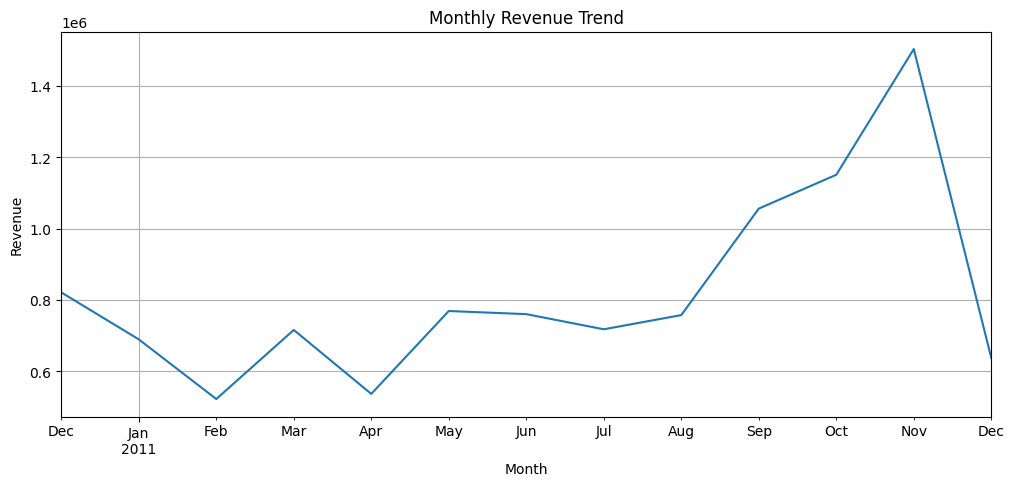

In [33]:
plt.figure(figsize=(12, 5))

monthly_sales.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)

plt.show()

In [34]:
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_sales = monthly_sales.min()

print(
    "Highest Sales Month:",
    highest_month,
    "| Sales:",
    round(highest_sales, 2)
)

print(
    "Lowest Sales Month:",
    lowest_month,
    "| Sales:",
    round(lowest_sales, 2)
)

Highest Sales Month: 2011-11-30 00:00:00 | Sales: 1503866.78
Lowest Sales Month: 2011-02-28 00:00:00 | Sales: 522545.56


### 📌 Business Insight

The monthly revenue trend shows noticeable variation across the observation period.

The highest- and lowest-performing months indicate that sales are not evenly distributed throughout the year. These variations are important for the later sales forecasting stage, where historical patterns will be used to estimate future revenue.

## 6.3 Monthly Order Volume

Monthly order volume is analyzed alongside revenue to understand changes in customer purchasing activity.

Comparing order volume with revenue helps determine whether changes in sales are driven by changes in the number of orders.

In [35]:
# ============================================
# 6.3 MONTHLY ORDER VOLUME
# ============================================

monthly_orders = (
    df.resample('ME', on='InvoiceDate')['Invoice']
    .nunique()
)

monthly_orders

,Invoice
InvoiceDate,
2010-12-31,1559
2011-01-31,1086
2011-02-28,1100
2011-03-31,1454
2011-04-30,1246
2011-05-31,1681
2011-06-30,1533
2011-07-31,1475
2011-08-31,1361


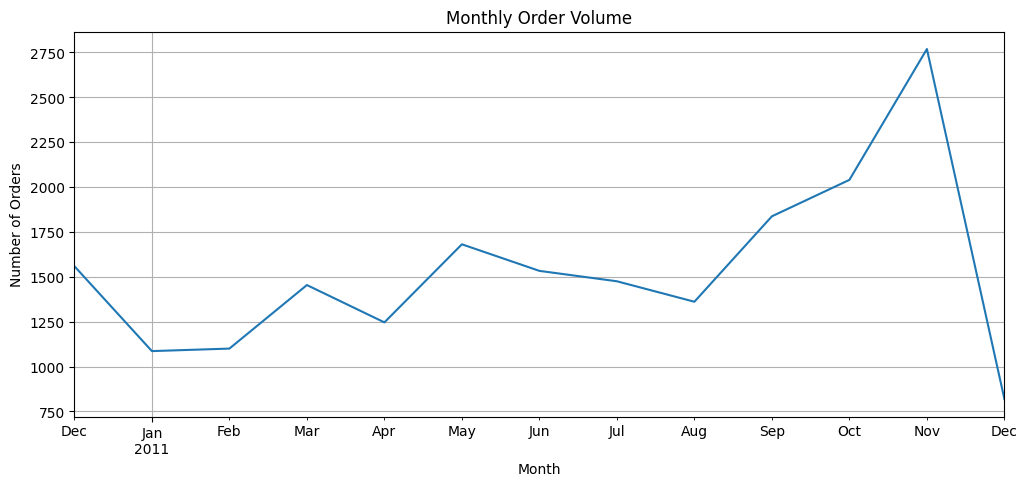

In [36]:
plt.figure(figsize=(12, 5))

monthly_orders.plot()

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.grid(True)

plt.show()

### 📌 Business Insight

November 2011 recorded both the highest monthly revenue and the highest order volume, indicating particularly strong purchasing activity during this period.

December 2011 shows the lowest order volume; however, this month should not be directly compared with complete months because the dataset ends on December 9, 2011. Therefore, December represents only a partial month.

In [37]:
highest_order_month = monthly_orders.idxmax()
highest_orders = monthly_orders.max()

lowest_order_month = monthly_orders.idxmin()
lowest_orders = monthly_orders.min()

print(
    "Highest Order Month:",
    highest_order_month,
    "| Orders:",
    highest_orders
)

print(
    "Lowest Order Month:",
    lowest_order_month,
    "| Orders:",
    lowest_orders
)

Highest Order Month: 2011-11-30 00:00:00 | Orders: 2769
Lowest Order Month: 2011-12-31 00:00:00 | Orders: 819


## 6.4 Average Order Value

Average Order Value (AOV) represents the average revenue generated per unique order.

**AOV = Total Revenue / Number of Orders**

This metric helps evaluate the average monetary value of customer orders.

In [38]:
# Calculate overall Average Order Value

average_order_value = total_revenue / unique_orders

print(
    "Average Order Value:",
    round(average_order_value, 2)
)

Average Order Value: 533.17


### 📌 Business Insight

Average Order Value provides an additional perspective on sales performance by measuring the average revenue generated per order.

Together, revenue, order volume, and AOV provide a more complete view of e-commerce performance and will support the later forecasting analysis.

## 6.5 Product Revenue Analysis

Product-level revenue is analyzed to identify the products that contribute the most to overall sales.

The analysis focuses on the top 10 products by total revenue.

In [39]:
# ============================================
# 6.5 TOP PRODUCTS BY REVENUE
# ============================================

product_revenue = (
    df.groupby('StockCode')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

top_10_products = product_revenue.head(10)

top_10_products

,Revenue
StockCode,
DOT,206248.77
22423,174156.54
23843,168469.60
85123A,104462.75
47566,99445.23
85099B,94159.81
23166,81700.92
POST,78119.88
M,77750.27


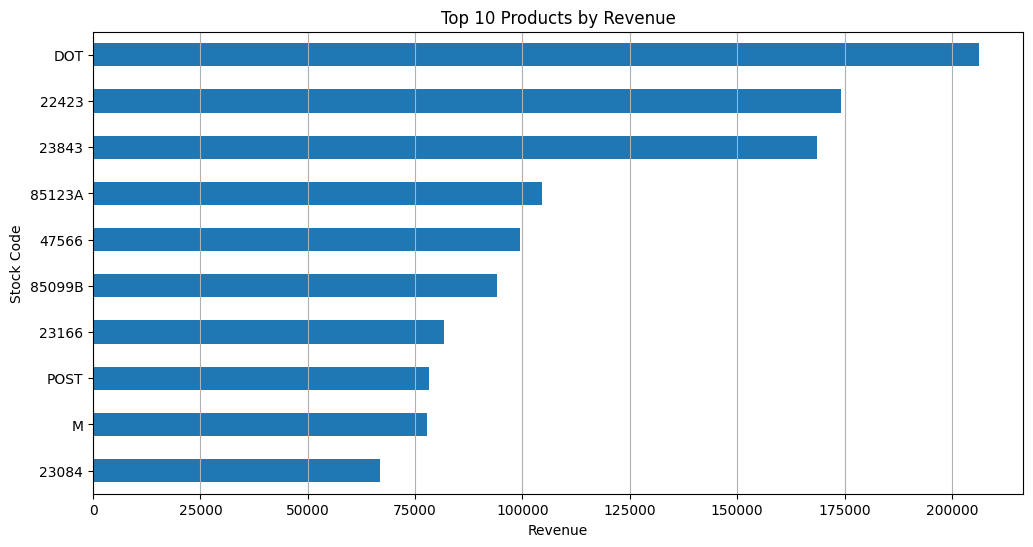

In [40]:
plt.figure(figsize=(12, 6))

top_10_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Stock Code')
plt.grid(axis='x')

plt.show()

## 6.6 Country-wise Revenue Analysis

Country-level revenue is analyzed to identify the major geographic markets contributing to overall e-commerce sales.

The top 10 countries by revenue are visualized for comparison.

In [41]:
# ============================================
# 6.6 COUNTRY-WISE REVENUE
# ============================================

country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

top_10_countries = country_revenue.head(10)

top_10_countries

,Revenue
Country,
United Kingdom,9001744.09
Netherlands,285446.34
EIRE,283140.52
Germany,228678.40
France,209643.37
Australia,138453.81
Spain,61558.56
Switzerland,57067.60
Belgium,41196.34


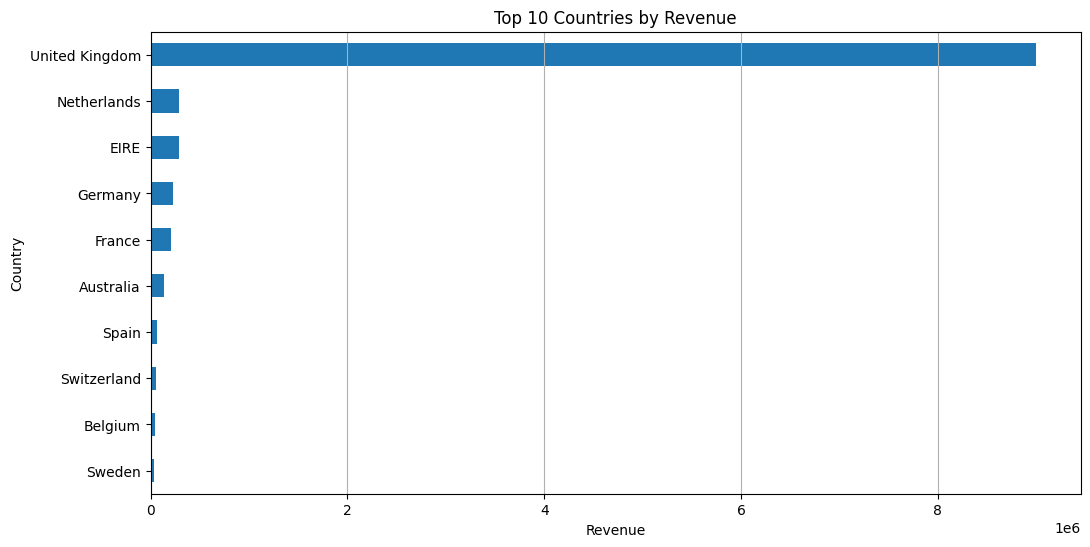

In [42]:
plt.figure(figsize=(12, 6))

top_10_countries.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.grid(axis='x')

plt.show()

### 📌 Business Insight

The revenue distribution is highly concentrated geographically.

The United Kingdom is the dominant market, generating approximately **9.00 million** in revenue. The remaining countries contribute substantially smaller amounts.

The top 10 countries collectively generate **97.21% of total revenue**, indicating that the business is highly dependent on a small number of geographic markets.

### 💡 Business Implication

This concentration suggests two important opportunities:

- Strengthen customer retention and marketing strategies in the major existing markets.
- Explore opportunities to expand into lower-contributing international markets to reduce geographic dependency.

In [43]:
top_10_country_revenue = top_10_countries.sum()

top_10_country_percentage = (
    top_10_country_revenue / total_revenue
) * 100

print(
    "Top 10 countries revenue:",
    round(top_10_country_revenue, 2)
)

print(
    "Revenue contribution of top 10 countries:",
    round(top_10_country_percentage, 2),
    "%"
)

Top 10 countries revenue: 10345296.86
Revenue contribution of top 10 countries: 97.21 %


### 📌 Business Insight

Country-level analysis helps identify the geographic markets that contribute most to overall revenue.

The concentration of revenue among the leading countries can help the business prioritize marketing, customer retention, inventory planning, and expansion strategies.

The top-10 country contribution will be used as an indicator of geographic sales concentration.

# 7. Customer RFM Analysis

RFM analysis is used to understand customer purchasing behavior.

RFM represents:

- **Recency:** How recently a customer made a purchase.
- **Frequency:** How often a customer made a purchase.
- **Monetary:** How much revenue a customer generated.

These features provide a behavioral representation of customers and will later be used for churn prediction.

In [44]:
# ============================================
# 7.1 CREATE CUSTOMER-LEVEL DATASET
# ============================================

customer_df = df.dropna(subset=['Customer ID']).copy()

print("Customer-level dataset shape:", customer_df.shape)
print("Unique customers:", customer_df['Customer ID'].nunique())

Customer-level dataset shape: (392689, 9)
Unique customers: 4338


In [45]:
# Set the analysis date

analysis_date = customer_df['InvoiceDate'].max()

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-09 12:50:00


In [46]:
# ============================================
# 7.2 CALCULATE RFM FEATURES
# ============================================

rfm = customer_df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("RFM Dataset Shape:", rfm.shape)

rfm.head()

RFM Dataset Shape: (4338, 3)


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [47]:
rfm['AverageOrderValue'] = (
    rfm['Monetary'] / rfm['Frequency']
).round(2)

rfm.head()

,Recency,Frequency,Monetary,AverageOrderValue
Customer ID,,,,
12346.0,325,1,77183.60,77183.60
12347.0,1,7,4310.00,615.71
12348.0,74,4,1797.24,449.31
12349.0,18,1,1757.55,1757.55
12350.0,309,1,334.40,334.40


In [48]:
rfm.describe()

,Recency,Frequency,Monetary,AverageOrderValue
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.692229,417.646710
std,100.014169,7.697998,8985.229676,1796.511231
min,0.000000,1.000000,3.750000,3.450000
25%,17.000000,1.000000,306.482500,177.862500
50%,50.000000,2.000000,668.570000,291.940000
75%,141.000000,5.000000,1660.597500,428.280000
max,373.000000,209.000000,280206.020000,84236.250000


# 8. Time-Based Churn Modeling

To create a realistic churn prediction problem, customer behavior is divided into an observation period and a future period.

### Observation Period

Historical transactions used to calculate customer behavior features such as Recency, Frequency, Monetary value, and Average Order Value.

### Future Period

Transactions occurring after the observation period are used to determine whether a customer remains active.

This approach uses past behavior to predict future customer inactivity and helps reduce target leakage.

In [49]:
# ============================================
# 8.1 DEFINE OBSERVATION PERIOD
# ============================================

observation_end = pd.Timestamp('2011-09-30 23:59:59')

print("Observation period ends:", observation_end)

Observation period ends: 2011-09-30 23:59:59


In [50]:
# Transactions used to build customer features
observation_data = customer_df[
    customer_df['InvoiceDate'] <= observation_end
].copy()

# Transactions used to determine future activity
future_data = customer_df[
    customer_df['InvoiceDate'] > observation_end
].copy()

print("Observation data shape:", observation_data.shape)
print("Future data shape:", future_data.shape)

Observation data shape: (263701, 9)
Future data shape: (128988, 9)


In [51]:
# ============================================
# 8.2 CREATE RFM FEATURES FROM OBSERVATION DATA
# ============================================

model_rfm = observation_data.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (
        observation_end - x.max()
    ).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

model_rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

model_rfm['AverageOrderValue'] = (
    model_rfm['Monetary'] /
    model_rfm['Frequency']
).round(2)

print("Model RFM shape:", model_rfm.shape)

model_rfm.head()

Model RFM shape: (3616, 4)


,Recency,Frequency,Monetary,AverageOrderValue
Customer ID,,,,
12346.0,255,1,77183.60,77183.60
12347.0,59,5,2790.86,558.17
12348.0,5,4,1797.24,449.31
12350.0,240,1,334.40,334.40
12352.0,2,7,2194.31,313.47


## 8.3 Define Churn Target

The churn target is based on customer activity during the future period.

- **Churn = 0:** Customer made at least one purchase during the future period.
- **Churn = 1:** Customer made no purchase during the future period.

This represents future customer inactivity and is used as a practical churn proxy.

In [52]:
# Customers who purchased during the future period

future_customers = set(
    future_data['Customer ID'].unique()
)

# Create churn target
model_rfm['Churn'] = (
    ~model_rfm.index.isin(future_customers)
).astype(int)

print(model_rfm['Churn'].value_counts())

print("\nChurn proportion:")
print(
    model_rfm['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn
0    1838
1    1778
Name: count, dtype: int64

Churn proportion:
Churn
0    50.83
1    49.17
Name: proportion, dtype: float64


In [53]:
print("Model Dataset Shape:", model_rfm.shape)

model_rfm.head()

Model Dataset Shape: (3616, 5)


,Recency,Frequency,Monetary,AverageOrderValue,Churn
Customer ID,,,,,
12346.0,255,1,77183.60,77183.60,1
12347.0,59,5,2790.86,558.17,0
12348.0,5,4,1797.24,449.31,1
12350.0,240,1,334.40,334.40,1
12352.0,2,7,2194.31,313.47,0


In [54]:
print(model_rfm.isnull().sum())

Recency              0
Frequency            0
Monetary             0
AverageOrderValue    0
Churn                0
dtype: int64


# 9. Machine Learning

Customer churn prediction is formulated as a binary classification problem.

### Input Features

- Recency
- Frequency
- Monetary
- Average Order Value

### Target

- Churn

Two machine learning algorithms will be evaluated:

1. Logistic Regression
2. Random Forest

In [55]:
# ============================================
# 9.1 PREPARE FEATURES AND TARGET
# ============================================

features = [
    'Recency',
    'Frequency',
    'Monetary',
    'AverageOrderValue'
]

X = model_rfm[features]
y = model_rfm['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3616, 4)
y shape: (3616,)


## 9.2 Train-Test Split

The dataset is divided into training and testing sets.

- **80%** of the data is used for training.
- **20%** is reserved for testing.

A fixed random state is used so that the results are reproducible.

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2892, 4)
X_test: (724, 4)
y_train: (2892,)
y_test: (724,)


## 9.3 Feature Scaling

The numerical features have different scales, particularly Monetary and Average Order Value.

Standardization transforms the features so that they have comparable scales.

This is important for Logistic Regression because the model is sensitive to feature magnitude.

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


## 9.4 Logistic Regression

Logistic Regression is used as the baseline classification model.

It estimates the probability that a customer belongs to the churn class.

The predicted classes are:

- **0 → Active**
- **1 → Churned / Future Inactivity**

In [58]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [59]:
y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


## 9.5 Logistic Regression Evaluation

The model is evaluated using multiple classification metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Using multiple metrics provides a more complete evaluation than accuracy alone.

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1 Score :", round(f1_lr, 4))
print("ROC-AUC  :", round(roc_auc_lr, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
--------------------------------
Accuracy : 0.674
Precision: 0.6571
Recall   : 0.7051
F1 Score : 0.6802
ROC-AUC  : 0.7453

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.64      0.67       368
           1       0.66      0.71      0.68       356

    accuracy                           0.67       724
   macro avg       0.68      0.67      0.67       724
weighted avg       0.68      0.67      0.67       724



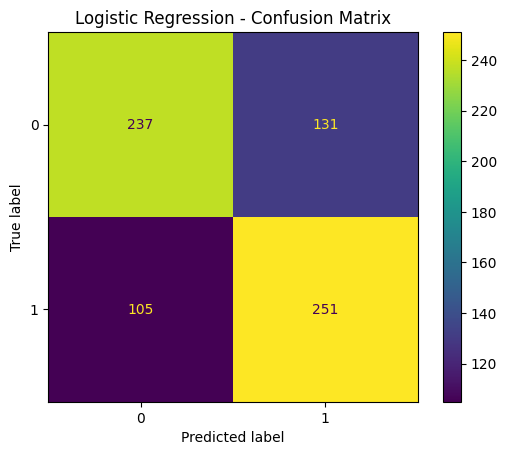

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
)

plt.title('Logistic Regression - Confusion Matrix')
plt.show()

## 10. Random Forest

Random Forest is used as a second classification model.

Unlike Logistic Regression, Random Forest can capture non-linear relationships between customer behavior features.

The model will be trained using:

- Recency
- Frequency
- Monetary
- Average Order Value

The performance will then be compared with Logistic Regression.

In [62]:
# ============================================
# 10.1 RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [63]:
# ============================================
# 10.2 RANDOM FOREST PREDICTIONS
# ============================================

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


In [64]:
# ============================================
# 10.3 RANDOM FOREST EVALUATION
# ============================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
--------------------------------
Accuracy : 0.6478
Precision: 0.6407
Recall   : 0.6461
F1 Score : 0.6434
ROC-AUC  : 0.7142

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.65      0.65       368
           1       0.64      0.65      0.64       356

    accuracy                           0.65       724
   macro avg       0.65      0.65      0.65       724
weighted avg       0.65      0.65      0.65       724



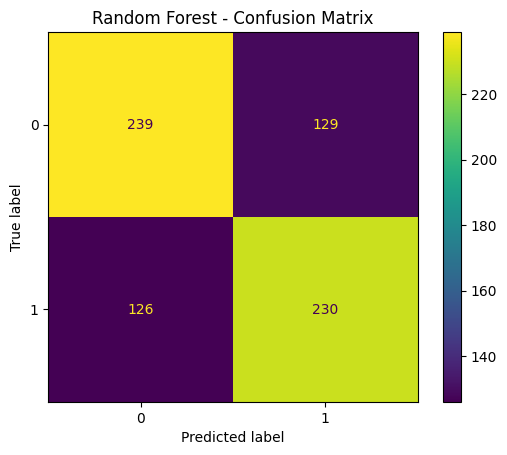

In [65]:
# ============================================
# 10.4 RANDOM FOREST CONFUSION MATRIX
# ============================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title('Random Forest - Confusion Matrix')
plt.show()

## 11. Model Comparison

The performance of Logistic Regression and Random Forest is compared using accuracy, precision, recall, F1-score, and ROC-AUC.

The comparison helps identify the most suitable model for customer churn prediction.

In [66]:
# ============================================
# 11.1 MODEL COMPARISON
# ============================================

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [0.6740, accuracy_rf],
    'Precision': [0.6571, precision_rf],
    'Recall': [0.7051, recall_rf],
    'F1 Score': [0.6802, f1_rf],
    'ROC-AUC': [0.7453, roc_auc_rf]
})

model_comparison = model_comparison.round(4)

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6740,0.6571,0.7051,0.6802,0.7453
1,Random Forest,0.6478,0.6407,0.6461,0.6434,0.7142


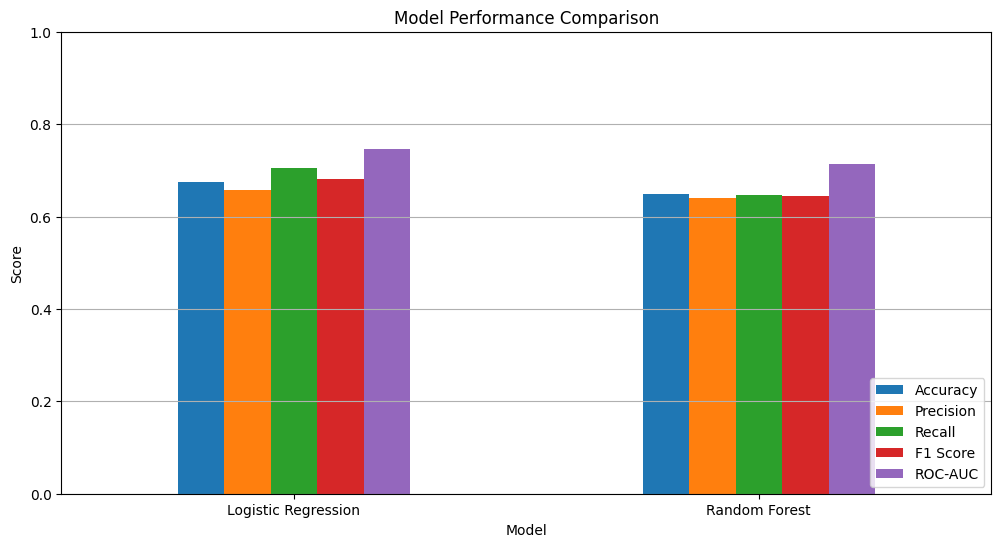

In [67]:
# ============================================
# 11.2 MODEL PERFORMANCE COMPARISON
# ============================================

model_comparison.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y')
plt.show()

## Model Selection

Based on the evaluation results, Logistic Regression performs better than Random Forest across all major evaluation metrics.

Logistic Regression achieved an Accuracy of 67.40% and ROC-AUC of 74.53%, compared with 64.78% Accuracy and 71.42% ROC-AUC for Random Forest.

Therefore, Logistic Regression is selected as the final baseline model for customer churn prediction.

## 12. Churn Driver Analysis

The Logistic Regression model is analyzed to understand the influence of each customer behavior feature on churn prediction.

The features considered are:

- Recency
- Frequency
- Monetary
- Average Order Value

The model coefficients are used to identify which features are associated with higher or lower churn risk.

In [68]:
# ============================================
# 12.1 LOGISTIC REGRESSION MODEL FOR
#     CHURN DRIVER ANALYSIS
# ============================================

from sklearn.linear_model import LogisticRegression

# Train Logistic Regression again with a clear variable name
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

print("Logistic Regression model ready for coefficient analysis!")

Logistic Regression model ready for coefficient analysis!


In [69]:
# ============================================
# 12.2 FEATURE COEFFICIENTS
# ============================================

feature_names = X.columns

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_model.coef_[0]
})

coefficients['Absolute Impact'] = coefficients['Coefficient'].abs()

coefficients = coefficients.sort_values(
    'Absolute Impact',
    ascending=False
)

display(coefficients)

,Feature,Coefficient,Absolute Impact
1,Frequency,-0.293587,0.293587
0,Recency,0.003652,0.003652
3,AverageOrderValue,0.000117,0.000117
2,Monetary,-0.000049,0.000049


## 12.3 Standardized Feature Impact

To compare the influence of the churn features fairly, the features are standardized before fitting Logistic Regression.

Standardization puts Recency, Frequency, Monetary, and Average Order Value on a comparable scale.

The resulting coefficients can therefore be compared to understand the relative influence of each feature on churn prediction.

In [70]:
# ============================================
# 12.3 STANDARDIZED FEATURE IMPACT
# ============================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create scaler
driver_scaler = StandardScaler()

# Scale training data
X_train_driver_scaled = driver_scaler.fit_transform(X_train)

# Train Logistic Regression on standardized features
driver_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

driver_model.fit(X_train_driver_scaled, y_train)

# Extract coefficients
feature_names = X.columns

driver_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': driver_model.coef_[0]
})

driver_coefficients['Absolute Impact'] = (
    driver_coefficients['Coefficient'].abs()
)

driver_coefficients = driver_coefficients.sort_values(
    'Absolute Impact',
    ascending=False
)

display(driver_coefficients)

,Feature,Coefficient,Absolute Impact
1,Frequency,-1.613799,1.613799
0,Recency,0.320421,0.320421
2,Monetary,-0.292962,0.292962
3,AverageOrderValue,0.186523,0.186523


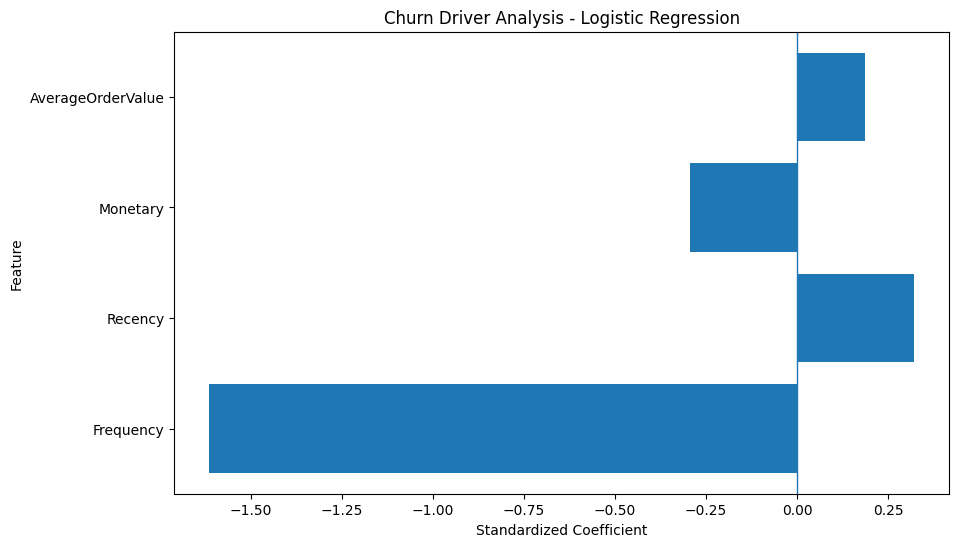

In [71]:
# ============================================
# 12.4 CHURN DRIVER VISUALIZATION
# ============================================

plt.figure(figsize=(10, 6))

plt.barh(
    driver_coefficients['Feature'],
    driver_coefficients['Coefficient']
)

plt.axvline(0, linewidth=1)

plt.title('Churn Driver Analysis - Logistic Regression')
plt.xlabel('Standardized Coefficient')
plt.ylabel('Feature')

plt.show()

## 13. Customer Churn Risk Prediction

The Logistic Regression model is used as the final churn prediction model.

Each customer's churn probability is calculated and converted into a risk category:

- Low Risk: churn probability < 30%
- Medium Risk: 30%–60%
- High Risk: > 60%

This allows the model output to be interpreted from a business perspective and can help identify customers who may require retention strategies.

In [72]:
# ============================================
# 13.1 CUSTOMER CHURN PROBABILITY
# ============================================

# Scale complete RFM dataset using the driver scaler
X_all_scaled = driver_scaler.transform(
    rfm[['Recency', 'Frequency', 'Monetary', 'AverageOrderValue']]
)

# Predict churn probability
rfm['Churn Probability'] = driver_model.predict_proba(
    X_all_scaled
)[:, 1]

print("Churn probabilities generated successfully!")

display(rfm.head())

Churn probabilities generated successfully!


,Recency,Frequency,Monetary,AverageOrderValue,Churn Probability
Customer ID,,,,,
12346.0,325,1,77183.60,77183.60,0.998922
12347.0,1,7,4310.00,615.71,0.153648
12348.0,74,4,1797.24,449.31,0.386116
12349.0,18,1,1757.55,1757.55,0.588104
12350.0,309,1,334.40,334.40,0.790469


In [73]:
# ============================================
# 13.2 CHURN RISK CATEGORIES
# ============================================

def assign_risk(probability):
    if probability < 0.30:
        return 'Low Risk'
    elif probability < 0.60:
        return 'Medium Risk'
    else:
        return 'High Risk'


rfm['Risk Category'] = rfm['Churn Probability'].apply(
    assign_risk
)

display(
    rfm[
        [
            'Recency',
            'Frequency',
            'Monetary',
            'AverageOrderValue',
            'Churn Probability',
            'Risk Category'
        ]
    ].head(10)
)

,Recency,Frequency,Monetary,AverageOrderValue,Churn Probability,Risk Category
Customer ID,,,,,,
12346.0,325,1,77183.60,77183.60,0.998922,High Risk
12347.0,1,7,4310.00,615.71,0.153648,Low Risk
12348.0,74,4,1797.24,449.31,0.386116,Medium Risk
12349.0,18,1,1757.55,1757.55,0.588104,Medium Risk
12350.0,309,1,334.40,334.40,0.790469,High Risk
12352.0,35,8,2506.04,313.26,0.140370,Low Risk
12353.0,203,1,89.00,89.00,0.714984,High Risk
12354.0,231,1,1079.40,1079.40,0.748960,High Risk
12355.0,213,1,459.40,459.40,0.727665,High Risk


Customer Risk Distribution:
Risk Category
Medium Risk    1977
High Risk      1319
Low Risk       1042
Name: count, dtype: int64


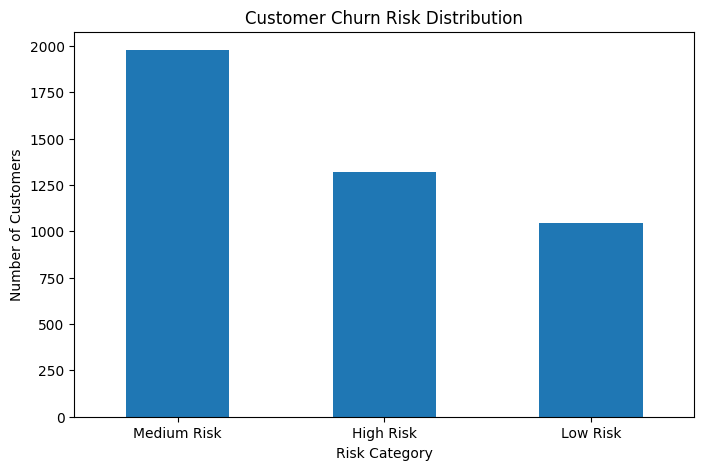

In [74]:
# ============================================
# 13.3 RISK DISTRIBUTION
# ============================================

risk_counts = rfm['Risk Category'].value_counts()

print("Customer Risk Distribution:")
print(risk_counts)

plt.figure(figsize=(8, 5))

risk_counts.plot(kind='bar')

plt.title('Customer Churn Risk Distribution')
plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

## 14. Business Insights

The customer churn analysis provides several actionable insights.

### Key Findings

1. **Recency is an important churn indicator**
   
   Customers with higher Recency values have generally been inactive for longer and show higher churn risk.

2. **Purchase Frequency is strongly associated with retention**
   
   Frequency has the strongest coefficient in the Logistic Regression model. Higher purchase frequency is associated with lower churn risk.

3. **Monetary value is associated with lower churn risk**
   
   Customers with higher historical spending tend to have lower predicted churn risk.

4. **Customer risk is distributed across three segments**
   
   Customers are categorized into Low, Medium, and High churn-risk groups based on their predicted churn probability.

5. **High-risk customers can be targeted for retention**
   
   Customers classified as High Risk can be prioritized for personalized offers, re-engagement campaigns, loyalty benefits, or other retention strategies.

## 15. High-Risk Customer Identification

Customers with a predicted churn probability of 60% or higher are classified as High Risk.

These customers can be prioritized for retention campaigns.

In [75]:
# ============================================
# 15.1 HIGH-RISK CUSTOMERS
# ============================================

high_risk_customers = rfm[
    rfm['Risk Category'] == 'High Risk'
].copy()

high_risk_customers = high_risk_customers.sort_values(
    'Churn Probability',
    ascending=False
)

print("High-risk customers:", len(high_risk_customers))

display(
    high_risk_customers.head(20)
)

High-risk customers: 1319


,Recency,Frequency,Monetary,AverageOrderValue,Churn Probability,Risk Category
Customer ID,,,,,,
12346.0,325,1,77183.60,77183.60,0.998922,High Risk
16754.0,371,1,2002.40,2002.40,0.842165,High Risk
13370.0,371,1,754.87,754.87,0.830058,High Risk
18074.0,373,1,489.60,489.60,0.828440,High Risk
15165.0,372,1,487.75,487.75,0.827897,High Risk
16718.0,368,1,606.05,606.05,0.826989,High Risk
15922.0,372,1,369.50,369.50,0.826700,High Risk
14729.0,373,1,313.49,313.49,0.826660,High Risk
16274.0,372,1,351.75,351.75,0.826520,High Risk


In [76]:
# ============================================
# 15.2 TOP HIGH-RISK CUSTOMERS
# ============================================

top_risk_customers = high_risk_customers[
    [
        'Recency',
        'Frequency',
        'Monetary',
        'AverageOrderValue',
        'Churn Probability',
        'Risk Category'
    ]
].head(20)

display(top_risk_customers)

,Recency,Frequency,Monetary,AverageOrderValue,Churn Probability,Risk Category
Customer ID,,,,,,
12346.0,325,1,77183.60,77183.60,0.998922,High Risk
16754.0,371,1,2002.40,2002.40,0.842165,High Risk
13370.0,371,1,754.87,754.87,0.830058,High Risk
18074.0,373,1,489.60,489.60,0.828440,High Risk
15165.0,372,1,487.75,487.75,0.827897,High Risk
16718.0,368,1,606.05,606.05,0.826989,High Risk
15922.0,372,1,369.50,369.50,0.826700,High Risk
14729.0,373,1,313.49,313.49,0.826660,High Risk
16274.0,372,1,351.75,351.75,0.826520,High Risk


## 16. Customer Risk Summary

Customers are grouped into three categories based on their predicted churn probability:

- **Low Risk:** Churn Probability < 0.30
- **Medium Risk:** 0.30 ≤ Churn Probability < 0.60
- **High Risk:** Churn Probability ≥ 0.60

This segmentation can help businesses prioritize customer retention strategies.

In [77]:
# ============================================
# 16. CUSTOMER RISK SUMMARY
# ============================================

risk_summary = (
    rfm['Risk Category']
    .value_counts()
    .reindex(['Low Risk', 'Medium Risk', 'High Risk'])
    .reset_index()
)

risk_summary.columns = ['Risk Category', 'Number of Customers']

risk_summary['Percentage'] = (
    risk_summary['Number of Customers']
    / len(rfm) * 100
).round(2)

display(risk_summary)

,Risk Category,Number of Customers,Percentage
0,Low Risk,1042,24.02
1,Medium Risk,1977,45.57
2,High Risk,1319,30.41


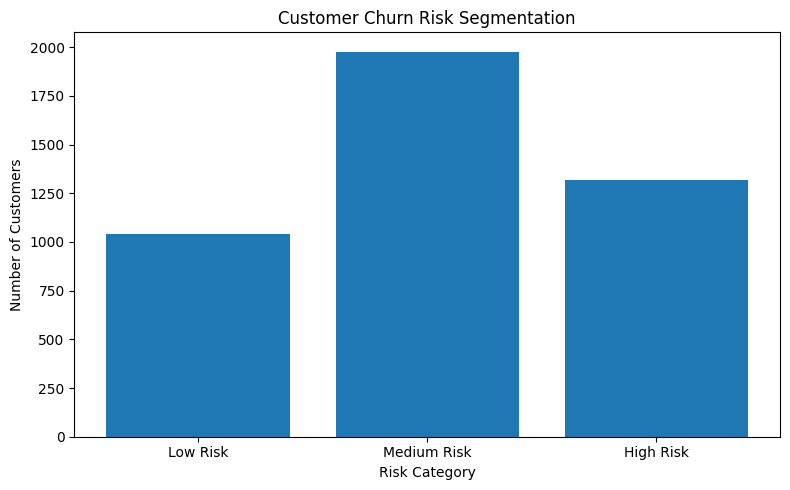

In [78]:
# ============================================
# 16.1 RISK SUMMARY VISUALIZATION
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary['Risk Category'],
    risk_summary['Number of Customers']
)

plt.title('Customer Churn Risk Segmentation')
plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [79]:
# ============================================
# 17. SAVE TRAINED MODEL AND SCALER
# ============================================

import joblib
import os

# Create models directory
os.makedirs("../models", exist_ok=True)

# Save Logistic Regression model
joblib.dump(log_model, "../models/churn_model.pkl")

# Save feature scaler
joblib.dump(scaler, "../models/scaler.pkl")

print("✅ Model saved successfully!")
print("✅ Scaler saved successfully!")

✅ Model saved successfully!
✅ Scaler saved successfully!


In [80]:
import os

print(os.listdir("../models"))

['churn_model.pkl', 'scaler.pkl']


In [81]:
from google.colab import files

files.download("../models/churn_model.pkl")
files.download("../models/scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>